# Hyperparameter Tuning of SVM 

## Objective

The goal of this project is to understand how model performance depends on hyperparameters.

In [2]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt

# Machine Learning utilities
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# SVM model
from sklearn.svm import SVC

# Hyperparameter tuning
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import RandomizedSearchCV

# Evaluation metrics
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix

# Bayesian Optimization
import optuna

import warnings
warnings.filterwarnings("ignore")

# To calculate time
import time

## Loading the Dataset

The dataset contains mobile phone specifications and the target variable: `price_range`

Price range classes:
- 0 = Low cost
- 1 = Medium cost
- 2 = High cost
- 3 = Very high cost

The objective is to predict the price category using mobile specifications.

In [3]:
df = pd.read_csv("mobile_price_classification.csv")

In [4]:
df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [6]:
df.isnull().sum() # checking for null values

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

## Splitting Features and Target

The target variable is `price_range`.

X contains input features.
y contains output classes.

In [7]:
# Separate features and target
X = df.drop("price_range", axis=1)
y = df["price_range"]

In [8]:
print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (2000, 20)
Target shape: (2000,)


## Train-Test Split

The dataset is divided into:
- 75% training data
- 25% testing data

Stratify is used to maintain the same class distribution in both sets.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.25,random_state=42,stratify=y)

## Feature Scaling

- SVM is a distance-based algorithm.
- Scaling is required because features such as RAM and battery power have different ranges.
- StandardScaler transforms features into a common scale.

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Baseline SVM Model

- Before tuning, we train an SVM model with default parameters.
- This gives us a performance baseline.

In [11]:
baseline_model = SVC()

baseline_model.fit(X_train_scaled,y_train)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [12]:
baseline_prediction = baseline_model.predict(X_test_scaled)

In [13]:
print("Baseline SVM classification report\n")
print(classification_report(y_test,baseline_prediction))

Baseline SVM classification report

              precision    recall  f1-score   support

           0       0.97      0.94      0.96       125
           1       0.83      0.85      0.84       125
           2       0.77      0.78      0.78       125
           3       0.89      0.90      0.89       125

    accuracy                           0.87       500
   macro avg       0.87      0.87      0.87       500
weighted avg       0.87      0.87      0.87       500



## Hyperparameter Tuning Using Grid Search

Grid Search tests every possible combination of hyperparameters.

Parameters tuned:
- C: Regularization strength
- Gamma: Influence of individual points
- Kernel: Decision boundary type

5-fold cross-validation is used for reliable evaluation.

In [14]:
param_grid = {

    "C":[0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000],
    "gamma":[1e-5, 1e-4, 1e-3, 0.01, 0.1, 1, 10],
    "kernel":["rbf"]

}

In [15]:
# Start timer
start_time = time.time()

grid_search = GridSearchCV(SVC(),param_grid,cv=5,scoring="accuracy",n_jobs=-1)
grid_search.fit(X_train_scaled,y_train)

# End timer
grid_time = time.time() - start_time

In [16]:
print("Best Parameters:")
print(grid_search.best_params_)
print('\n')

print("Best CV Accuracy:")
print(grid_search.best_score_)
print("\n")

print("Grid Search Time:")
print(round(grid_time, 3), "seconds")

Best Parameters:
{'C': 10000, 'gamma': 0.0001, 'kernel': 'rbf'}


Best CV Accuracy:
0.9513333333333331


Grid Search Time:
11.898 seconds


In [17]:
grid_prediction = grid_search.predict(X_test_scaled)

print("Grid Search Classification Report\n")
print(classification_report(y_test,grid_prediction))

Grid Search Classification Report

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       125
           1       0.94      0.96      0.95       125
           2       0.96      0.96      0.96       125
           3       0.98      0.99      0.99       125

    accuracy                           0.97       500
   macro avg       0.97      0.97      0.97       500
weighted avg       0.97      0.97      0.97       500



## Hyperparameter Tuning Using Random Search

Random Search selects random combinations from the parameter space.

It is faster than Grid Search when many hyperparameters exist.

In [18]:
# Start timer
start_time = time.time()

random_search = RandomizedSearchCV(SVC(),param_grid,n_iter=10,cv=5,scoring="accuracy",random_state=42,n_jobs=-1)
random_search.fit(X_train_scaled,y_train)

# End timer
random_time = time.time() - start_time

In [19]:
print("Best Parameters:")
print(random_search.best_params_)
print('\n')

print("Best CV Accuracy:")
print(random_search.best_score_)

print("\nRandom Search Time:")
print(round(random_time, 3), "seconds")

Best Parameters:
{'kernel': 'rbf', 'gamma': 0.0001, 'C': 10000}


Best CV Accuracy:
0.9513333333333331

Random Search Time:
1.848 seconds


In [20]:
random_prediction = random_search.predict(X_test_scaled)

print("Random Search Classification Report\n")
print(classification_report(y_test,random_prediction))

Random Search Classification Report

              precision    recall  f1-score   support

           0       0.99      0.97      0.98       125
           1       0.94      0.96      0.95       125
           2       0.96      0.96      0.96       125
           3       0.98      0.99      0.99       125

    accuracy                           0.97       500
   macro avg       0.97      0.97      0.97       500
weighted avg       0.97      0.97      0.97       500



## Bayesian Optimization Using Optuna

Bayesian Optimization learns from previous trials and selects better hyperparameter combinations.

It balances:
- Exploration of new values
- Exploitation of promising values

In [28]:
def objective(trial):
    
    C = trial.suggest_float("C",0.1,10000,log=True)

    gamma = trial.suggest_float("gamma",0.001,1,log=True)

    model = SVC(C=C,gamma=gamma,kernel="rbf")

    model.fit(X_train_scaled,y_train)

    accuracy = model.score(X_test_scaled,y_test)

    return accuracy


In [29]:
# Start timer
start_time = time.time()

study = optuna.create_study(direction="maximize")

[I 2026-07-24 16:10:46,685] A new study created in memory with name: no-name-f37113c1-6a0a-4d77-a1a1-6c994e2043f8


In [30]:
study.optimize(objective,n_trials=30)

# End time
bayesian_time = time.time() - start_time

[I 2026-07-24 16:10:47,788] Trial 0 finished with value: 0.254 and parameters: {'C': 0.5898920995497388, 'gamma': 0.8723283701209278}. Best is trial 0 with value: 0.254.
[I 2026-07-24 16:10:47,899] Trial 1 finished with value: 0.848 and parameters: {'C': 0.9049102029203172, 'gamma': 0.003208816383856326}. Best is trial 1 with value: 0.848.
[I 2026-07-24 16:10:48,036] Trial 2 finished with value: 0.636 and parameters: {'C': 0.28948779442308503, 'gamma': 0.15604073107621036}. Best is trial 1 with value: 0.848.
[I 2026-07-24 16:10:48,180] Trial 3 finished with value: 0.452 and parameters: {'C': 292.8085394772434, 'gamma': 0.5586490116260789}. Best is trial 1 with value: 0.848.
[I 2026-07-24 16:10:48,272] Trial 4 finished with value: 0.878 and parameters: {'C': 8822.846604053098, 'gamma': 0.03812360718184923}. Best is trial 4 with value: 0.878.
[I 2026-07-24 16:10:48,361] Trial 5 finished with value: 0.88 and parameters: {'C': 1236.9910519359446, 'gamma': 0.03344181282829603}. Best is tria

In [31]:
print("Best Parameters:")
print(study.best_params)
print('\n')

print("Best Accuracy:")
print(study.best_value)

print("\nBayesian Optimization Time:")
print(round(bayesian_time,3),"seconds")

Best Parameters:
{'C': 147.51326197267423, 'gamma': 0.001265676611293546}


Best Accuracy:
0.958

Bayesian Optimization Time:
3.532 seconds


# Final Model Selection

The model with the highest validation performance is selected.

Usually Bayesian Optimization requires fewer trials while finding competitive hyperparameters.

In [32]:
best_model = SVC(
    C=study.best_params["C"],
    gamma=study.best_params["gamma"],
    kernel="rbf")

In [33]:
best_model.fit(X_train_scaled,y_train)

final_prediction = best_model.predict(X_test_scaled)

In [34]:
print("Best Model Classification Report\n")
print(classification_report(y_test,final_prediction))

Best Model Classification Report

              precision    recall  f1-score   support

           0       0.98      0.95      0.97       125
           1       0.94      0.96      0.95       125
           2       0.95      0.94      0.95       125
           3       0.96      0.98      0.97       125

    accuracy                           0.96       500
   macro avg       0.96      0.96      0.96       500
weighted avg       0.96      0.96      0.96       500



## Confusion Matrix

The confusion matrix shows how well the model classifies each price category.

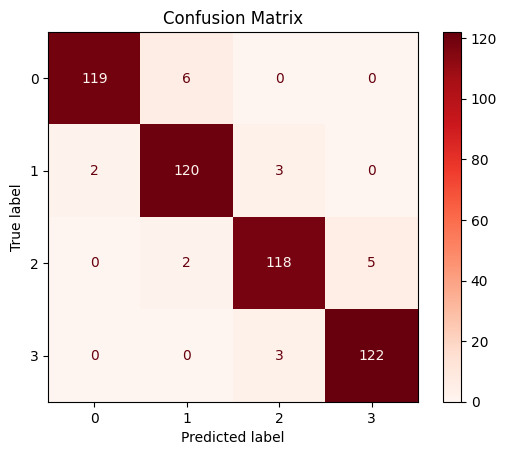

In [35]:
cm = confusion_matrix(y_test,final_prediction)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Reds")

plt.title("Confusion Matrix")
plt.show()

## Comparison of Hyperparameter Optimization Methods

The execution time of different optimization methods is compared.

This helps understand the trade-off between:
- Search efficiency
- Computational cost
- Model performance

In [36]:
comparison = pd.DataFrame({

    "Method":[
        "Grid Search",
        "Random Search",
        "Bayesian Optimization"
    ],

    "Time (seconds)":[
        grid_time,
        random_time,
        bayesian_time
    ],

    "Accuracy":[
        grid_search.best_score_,
        random_search.best_score_,
        study.best_value
    ]

})

comparison

,Method,Time (seconds),Accuracy
0,Grid Search,11.897860,0.951333
1,Random Search,1.847581,0.951333
2,Bayesian Optimization,3.531637,0.958000


## Execution Time Comparison of Optimization Methods

The execution time of each hyperparameter tuning technique is visualized to compare their computational efficiency.

This comparison helps understand the trade-off between:
- Search accuracy
- Number of model evaluations
- Computational cost

Generally:
- **Grid Search** takes more time because it evaluates every possible combination of hyperparameters.
- **Random Search** is faster because it tests only a fixed number of randomly selected combinations.
- **Bayesian Optimization** can reduce computation by using previous results to intelligently select the next hyperparameter values.

The bar chart below shows the time taken by each optimization method.

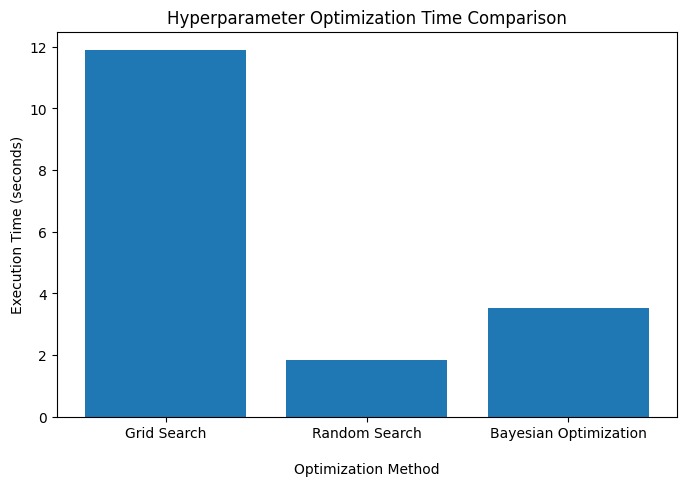

In [37]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison["Method"],
    comparison["Time (seconds)"]
)

plt.ylabel("Execution Time (seconds)")
plt.xlabel("\nOptimization Method")

plt.title("Hyperparameter Optimization Time Comparison")

plt.show()

# Conclusion

Hyperparameter tuning improved the performance of the SVM model by finding better combinations of parameters such as **C** and **gamma**.

**Key observations:**

- Feature scaling is essential for SVM because it relies on distance calculations between data points.
- Cross-validation provides a more reliable estimate of model performance and helps prevent selecting overfitted hyperparameters.
- Grid Search provides an exhaustive search and can find the best combination within the defined parameter space, but it requires higher computational time.
- Random Search reduces computation by evaluating only a subset of possible combinations while still achieving competitive performance.
- Bayesian Optimization efficiently explores the hyperparameter space by learning from previous trials, often achieving good results with fewer evaluations.
- Execution time comparison shows the trade-off between optimization accuracy and computational cost.

The final SVM model is selected based on evaluation metrics such as **Accuracy, Precision, Recall, and F1-score**, along with consideration of computational efficiency.